# Notebook 4 — Style Transfer & Portfolio Generation

**Phase 3/4** deliverable. This notebook focuses on applying your
CycleGAN/Pix2Pix models to real style-transfer data (e.g. WikiArt), then
using the platform's export pipeline to build your 50+ image Generated Art
Portfolio (`outputs/portfolio/`).

Make sure `pytest -m advanced -v` and `pytest -m platform -v` pass before
relying on the helpers used here.


In [7]:
%matplotlib inline

import sys
from pathlib import Path

# Make `generative_art_studio` importable without `pip install -e .`
# REPO_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() else Path.cwd()
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import torch
from generative_art_studio.utils import set_seed, plot_image_grid
from generative_art_studio.config import DEVICE

set_seed(42)
print(f"Using device: {DEVICE}")


Using device: cuda


## 1. Load a style-transfer dataset

Download WikiArt (or another style dataset) first — see `docs/SETUP.md`
and `scripts/download_data.py --dataset wikiart --out data/wikiart`.


In [8]:
from generative_art_studio.data import get_image_dataset, get_dataloader

# TODO: point this at your downloaded style dataset once available.
style_dataset = get_image_dataset(REPO_ROOT / "data"/"wikiart", image_size=64)
style_dataloader = get_dataloader(style_dataset, batch_size=16)

print("Dataset size:", len(style_dataset))
print("Classes:", style_dataset.classes)


Dataset size: 10000
Classes: ['content', 'style']


In [9]:
print("Dataset path:", REPO_ROOT / "data" / "wikiart")
print("Dataset exists:", (REPO_ROOT / "data" / "wikiart").exists())
print("Dataset size:", len(style_dataset))
print("Classes:", style_dataset.classes)

images, labels = next(iter(style_dataloader))

print("Batch shape:", images.shape)
print("Labels:", labels)

Dataset path: c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Generative Art Studio\generative-art-studio-nagasantoshchavvakula\data\wikiart
Dataset exists: True
Dataset size: 10000
Classes: ['content', 'style']
Batch shape: torch.Size([16, 3, 64, 64])
Labels: tensor([0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1])


## 2. Apply your trained CycleGAN/Pix2Pix generator

Load a checkpoint you saved while training in Notebook 3, run it over a
batch of content images, and visualize input vs. stylized output
side-by-side.


In [10]:
# TODO: load a trained generator checkpoint and run style transfer here
# e.g.
# from generative_art_studio.models.advanced import CycleGANGenerator
# generator = CycleGANGenerator(features=32, num_residual_blocks=4).to(DEVICE)
# generator.load_state_dict(torch.load("checkpoints/cyclegan_a2b.pt", map_location=DEVICE))
# generator.eval()
from generative_art_studio.models.advanced import CycleGANGenerator

generator = CycleGANGenerator(
    features=32,
    num_residual_blocks=4,
).to(DEVICE)

checkpoint_path = REPO_ROOT / "checkpoints" / "cyclegan_a2b.pt"

generator.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )
)

generator.eval()

print("Loaded checkpoint:", checkpoint_path)

Loaded checkpoint: c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Generative Art Studio\generative-art-studio-nagasantoshchavvakula\checkpoints\cyclegan_a2b.pt


### run actual content → style transfer

In [11]:
from torch.utils.data import Subset

content_indices = [
    i
    for i, label in enumerate(style_dataset.targets)
    if label == style_dataset.class_to_idx["content"]
]

content_dataset = Subset(
    style_dataset,
    content_indices,
)

content_dataloader = get_dataloader(
    content_dataset,
    batch_size=8,
)

content_images, _ = next(iter(content_dataloader))
content_images = content_images.to(DEVICE)

with torch.no_grad():
    stylized_images = generator(content_images)

print("Content:", content_images.shape)
print("Stylized:", stylized_images.shape)

Content: torch.Size([8, 3, 64, 64])
Stylized: torch.Size([8, 3, 64, 64])


### Visualize

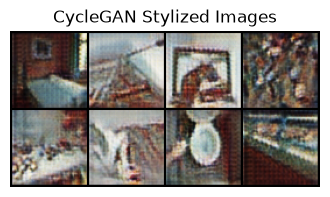

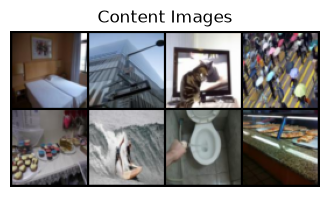

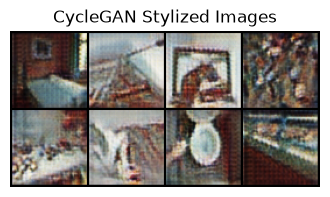

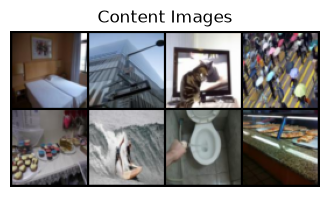

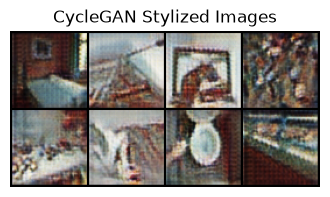

In [12]:
plot_image_grid(
    content_images.cpu(),
    nrow=4,
    title="Content Images",
)

plot_image_grid(
    stylized_images.cpu(),
    nrow=4,
    title="CycleGAN Stylized Images",
)

## 3. Style mixing & interpolation

Reuse `interpolate_latent` (VAE) or interpolate between two *content*
images fed through your style-transfer generator to create a smooth
transition sequence — a nice portfolio piece.


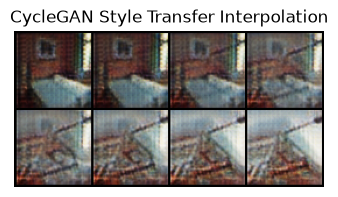

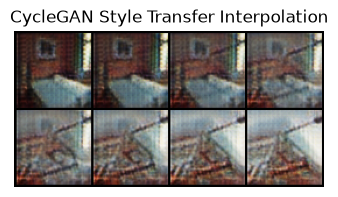

In [13]:
# TODO: build an interpolation grid, e.g. blend two source images before
# feeding them through your generator, or interpolate a VAE latent path
# and decode each step (see Notebook 1).
with torch.no_grad():
    image_a = content_images[0:1]
    image_b = content_images[1:2]

    interpolation_steps = 8
    interpolated_images = []

    for alpha in torch.linspace(
        0,
        1,
        interpolation_steps,
        device=DEVICE,
    ):
        blended = (1 - alpha) * image_a + alpha * image_b
        stylized = generator(blended)
        interpolated_images.append(
            stylized.squeeze(0).cpu()
        )

interpolated_images = torch.stack(interpolated_images)

plot_image_grid(
    interpolated_images,
    nrow=4,
    title="CycleGAN Style Transfer Interpolation",
)

## 4. Build your Generated Art Portfolio

Use `generative_art_studio.app.model_registry` — the same code your
Streamlit platform (Phase 4) uses — to generate and export high-resolution
images into `outputs/portfolio/`. Implement `generate_samples` and
`export_image` in `app/model_registry.py` first (`pytest -m platform -v`).


In [14]:
from generative_art_studio.app.model_registry import load_model, generate_samples, export_image

vae_model = load_model("vae", device=DEVICE)
gan_model = load_model("vanilla_gan", device=DEVICE)

portfolio_dir = REPO_ROOT / "outputs" / "portfolio"
count = 0
for model_key, model in [("vae", vae_model), ("vanilla_gan", gan_model)]:
    images = generate_samples(model_key, model, num_samples=25, seed=count, device=DEVICE)
    for i, img in enumerate(images):
        export_image(img, portfolio_dir / f"{model_key}_samples" / f"{model_key}_{i:03d}.png", scale_factor=4)
        count += 1

print(f"Exported {count} portfolio images to {portfolio_dir}")


Exported 50 portfolio images to c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Generative Art Studio\generative-art-studio-nagasantoshchavvakula\outputs\portfolio


## Reflection (for your Technical Report / Presentation)

- Which model produced your favorite portfolio pieces, and why (artistic
  judgment, not just metrics)?
- What would you improve about the style-transfer results with more
  training time or a different architecture?
- Record your 10–12 minute video presentation demonstrating the platform
  (`streamlit run src/generative_art_studio/app/streamlit_app.py`) and
  walking through this portfolio.
